In [1]:
import pandas as pd

df = pd.read_csv("train.csv")

print("Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nNull Values:")
print(df.isnull().sum())

print("\nUnique Values:")
print(df.nunique())

print("\nDataset Preview:")
print(df.head())

Shape:
(891, 12)

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Null Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Unique Values:
PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

Dataset Preview:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3     

In [2]:
df["Age"].fillna(df["Age"].median(), inplace=True)

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

df["Cabin"].fillna("Unknown", inplace=True)

/tmp/ipykernel_1000/225682810.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipykernel_1000/225682810.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [3]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df["Fare"] >= lower) &
    (df["Fare"] <= upper)
]

In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["Age"] = scaler.fit_transform(df[["Age"]])
df["Fare"] = scaler.fit_transform(df[["Fare"]])

In [5]:
df.to_csv("cleaned_titanic.csv", index=False)

In [6]:
import sqlite3

conn = sqlite3.connect("titanic_analytics.db")

df.to_sql(
    "passengers",
    conn,
    if_exists="replace",
    index=False
)

print("Data Loaded Successfully")

Data Loaded Successfully


In [7]:
query = """
SELECT
Pclass,
COUNT(*) AS Passenger_Count
FROM passengers
GROUP BY Pclass
"""

result = pd.read_sql_query(query, conn)

print(result)

   Pclass  Passenger_Count
0       1              112
1       2              179
2       3              484


In [9]:
query = """
SELECT
Pclass,
AVG(Fare) AS Average_Fare
FROM passengers
GROUP BY Pclass
"""

avg_fare = pd.read_sql_query(query, conn)

print(avg_fare)

   Pclass  Average_Fare
0       1      0.570046
1       2      0.295173
2       3      0.197961


In [8]:
query = """
SELECT
Sex,
AVG(Survived)*100 AS Survival_Rate
FROM passengers
GROUP BY Sex
"""

survival = pd.read_sql_query(query, conn)

print(survival)

      Sex  Survival_Rate
0  female      68.852459
1    male      17.890772


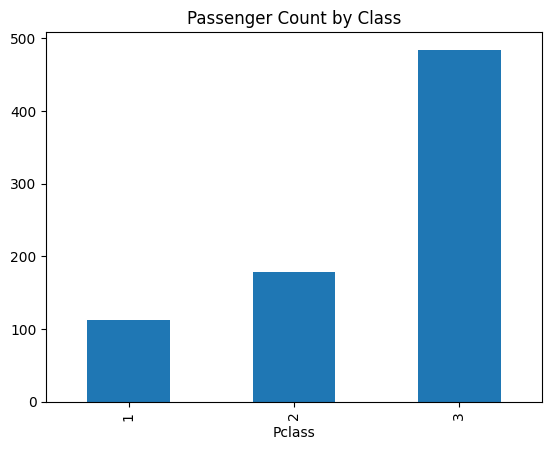

In [10]:
import matplotlib.pyplot as plt

result.plot(
    kind="bar",
    x="Pclass",
    y="Passenger_Count",
    legend=False
)

plt.title("Passenger Count by Class")
plt.show()

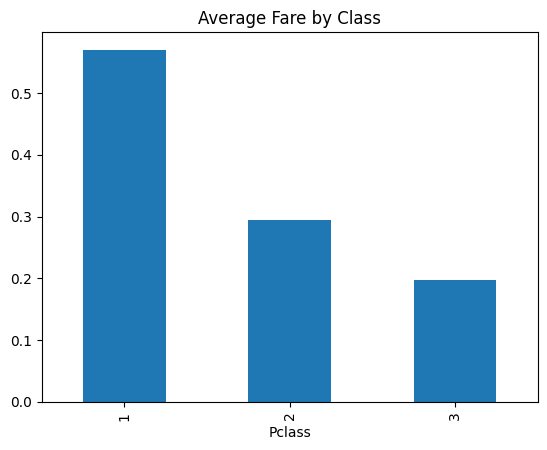

In [11]:
avg_fare.plot(
    kind="bar",
    x="Pclass",
    y="Average_Fare",
    legend=False
)

plt.title("Average Fare by Class")
plt.show()

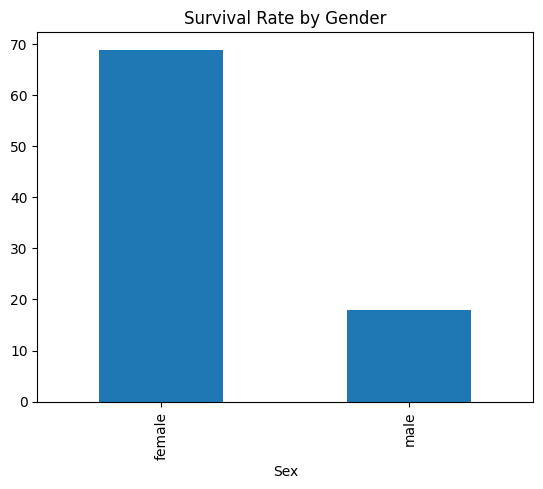

In [12]:
survival.plot(
    kind="bar",
    x="Sex",
    y="Survival_Rate",
    legend=False
)

plt.title("Survival Rate by Gender")
plt.show()